In [1]:
# Installing Hugging Face datasets
!pip install datasets==3.6.0 --quiet
!pip install git+https://github.com/MultimodalUniverse/MultimodalUniverse.git --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from datasets import load_dataset
# Import pandas
import pandas as pd
# Import numpy
import numpy as np
# Import the plotting functions from matplotlib
import matplotlib.pyplot as plt
import os
import seaborn as sns
from datasets import load_dataset_builder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import skew

### Part 0

For tis assignment I choose the PLAsTiCC dataset for supernovas that includes time series and tabular data. Moreover the lightcurve constitutes a multivariate time series (flux measurements across spectral bands), while the remaining features are static tabular variables, resulting in a heterogeneous multimodal dataset!

In [3]:
dset_plasticc = load_dataset("MultimodalUniverse/plasticc",
                       streaming=True,
                       split='train')
dset_plasticc = dset_plasticc.with_format("numpy")
dset_iterator = iter(dset_plasticc)
example = next(dset_iterator)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

#Part 1 -Exploratory Data Analysis

## 3.1 Data Encoding & Representation

## What does X matrix represent?<br>
Initially, 21 features were considered across the two modalities (tabular and compressed time series features). However, exploratory data analysis revealed that the Y-band photometric data contained zero-valued entries across the entire sampled population. Since features with zero variance provide no discriminative power for classification, the Y-band descriptors (mean, standard deviation, slope and maximum flux) were excluded. The final data matrix $X \in \mathbb{R}^{7848 \times 23}$ thus consists of 3 metadata features and 20 time-series features (4 stats $\times$ 5 active bands: $u, g, r, i, z$).<br>
## More explicitly the features of each modality are:<br>
1) Astrophysical Metadata (Tabular) - 3 first columns of matrix X

- hostgal_photoz: The estimated distance of the host galaxy.<br>
- hostgal_specz: The precise distance.<br>
- redshift: The overall shift in light, crucial for distinguishing between local stars (M-dwarf, Mira) and distant supernovae.
<br>

2)  Light Curve Dynamics (Derived from Time-Series) for each one of the 6 bands ($u, g, r, i, z$) - the next 20 columns of the X matrix.

- Band-Averaged Flux: Mean flux for each of the 6 filters ($u, g, r, i, z$).<br>
 - Flux Variability: Standard deviation of flux per band (this helps distinguish steady stars from explosive supernovae).<br>
- Peak Brightness: The maximum flux recorded (essential for "Standard Candle" objects like SNIa).
- Slope of the Time series which I calculated using a linear regression coefficient ($m$) that captures the global rate of change in brightness over time, distinguishing between rapidly evolving transients and steady-state objects."

## What does Y vector represent?<br>
The target vector $y \in \mathbb{R}^{7848}$ represents the astrophysical classification of each object, encoded as integers corresponding to the 14 unique labels in the PLAsTiCC dataset.

In [4]:
X_list = []
y_labels = []

# our bands
bands = ['u', 'g', 'r', 'i', 'z']

for ex in dset_plasticc:
    # --- 1. Extract Target (y) ---
    y_labels.append(ex['obj_type'])

    # --- 2. Extract Metadata (3 features) ---
    meta = [
        float(ex.get('redshift', 0.0) or 0.0),
        float(ex.get('hostgal_photoz', 0.0) or 0.0),
        float(ex.get('hostgal_specz', 0.0) or 0.0)
    ]

    # --- 3. Extract Time-Series Stats (24 features) ---
    ts_features = []
    lc = ex['lightcurve']

    for b in bands:
        # Filter flux and time for the specific band
        m = lc['band'] == b
        b_flux = lc['flux'][m]
        b_time = lc['time'][m]

        b_flux = np.array(b_flux)
        b_time = np.array(b_time)

        if len(b_flux) > 1:
            try:
                # Calculate Stats
                f_mean = np.nanmean(b_flux)
                f_std = np.nanstd(b_flux)
                f_max = np.nanmax(b_flux)

                # Use a try-except for the polyfit math
                # We also check if all b_time values are the same to avoid division by zero
                if np.unique(b_time).size > 1:
                    m, b_val = np.polyfit(b_time, b_flux, 1) # This fits a first-degree polynomial (a straight line) to our data.
                else:
                    m = 0.0
            except np.linalg.LinAlgError:
                # If the math fails to converge, we default the slope to 0
                m = 0.0
        else:
            # Default values for empty or single-point bands
            f_mean, f_std, f_max,m = 0.0, 0.0, 0.0, 0.0


        ts_features.extend([f_mean, f_std, f_max,m])

    # Concatenate all features into one row
    X_list.append(meta + ts_features)

# Convert to final Numpy Arrays
X = np.array(X_list)

# --- 4. Final Preprocessing ---
# Encode the "Names" into integers
le = LabelEncoder()
y = le.fit_transform(y_labels)

# Scale the Matrix X (Crucial for Slope vs Flux vs Redshift)
scaler = StandardScaler() # applied the Z-score transformation to every single cell in the matrix where μ is the mean of that column and σ is the standard deviation.
X_scaled = scaler.fit_transform(X)

print(f"Final X Matrix Shape: {X_scaled.shape}")
# print(X_scaled)
# print("Y",y)

Final X Matrix Shape: (7848, 23)


## Data Matrix Dimensions:

The data matrix is defined as $X \in \mathbb{R}^{7848 \times 23}$
- n=7848$ (Rows): Each row represents a single astronomical object (a unique sample) from the PLAsTiCC dataset.
- d = 23 (Columns): Each column represents a specific feature extracted from the two modalities (3 tabular features + 20 time-series features across 5 active bands).

Feature Types

- Continuous Features: All 23 features in X are encoded as continuous floating-point numbers. This includes the physical redshift values and the statistical descriptors of the light curves (mean, standard deviation, maximum flux, and linear slope).

- Categorical Features: There are no categorical features in X. The original categorical "obj_type" values were moved to the target vector y and converted to integers via Label Encoding.

- Spectral Information: While the data is not a raw spectrum, spectral information is implicitly encoded through the multiband photometry (u,g,r,i,z).

Handling Missing Values Band Filtering:

- Any photometric band with fewer than two observations was treated as missing.
- Data Imputation: For these cases, we applied Constant Imputation ($0.0$). This is physically justified in astronomy: if an object is not detected in a specific filter, its flux is effectively at the noise floor of the telescope.

Feature Scaling Standardization (Z-score Normalization):

-  Because flux values (range $\approx 10^2$) and redshift values (range $0-3$) exist on vastly different scales, we applied a StandardScaler. Each feature $x$ was transformed such that its new distribution has $\mu = 0$ and $\sigma = 1$. This prevents the model from being biased toward high-magnitude flux features and ensures the "Slope" (often a very small decimal) is weighted equally.

## 3.2 Similarity & Inner Product

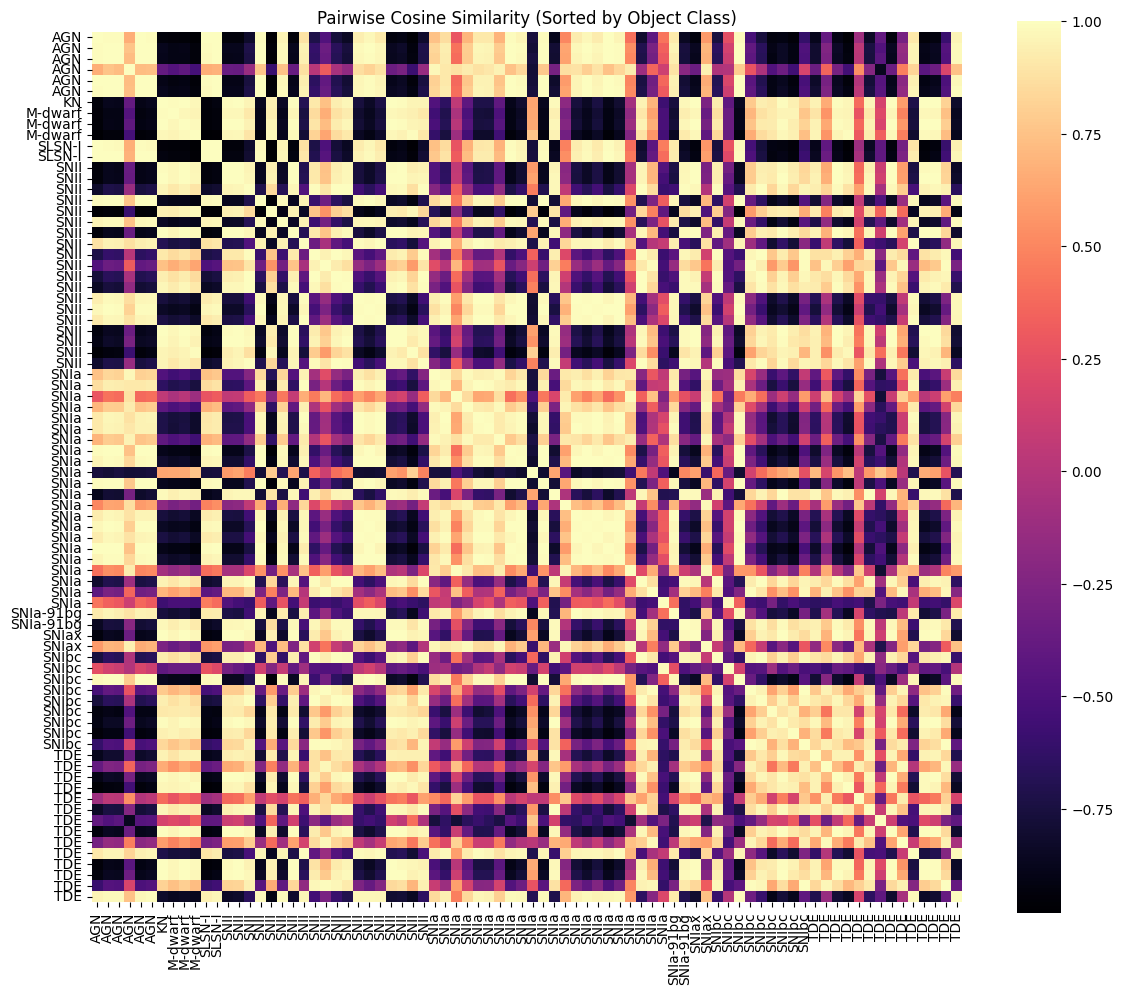

In [5]:
subset_size = 80

#from above
X_sub = X_scaled[:subset_size]
y_sub = y[:subset_size]

# Keep the original string names for the axis labels
names_sub = np.array(y_labels)[:subset_size]

# 2. SORT the subset by class (secret to a good heatmap)
sort_idx = np.argsort(y_sub) #creates a list of indices (the "original positions") that tells you which order to put things in to get them sorted
X_sorted = X_sub[sort_idx]
names_sorted = names_sub[sort_idx]

# 3. Compute Pairwise Cosine Similarity
sim_matrix = cosine_similarity(X_sorted)

# 4. Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix,
            cmap='magma',
            xticklabels=names_sorted,
            yticklabels=names_sorted,
            square=True)

plt.title('Pairwise Cosine Similarity (Sorted by Object Class)')
plt.tight_layout()
plt.show()

- Bright Yellow/White: High similarity ($\approx 1.0$). These objects look almost identical to the model.
- Dark Purple/Black: High dissimilarity (negative or near 0). These objects are completely different.

The sorted heatmap of pairwise cosine similarities reveals distinct block-diagonal structures, particularly for classes such as M-dwarf and TDE. These bright yellow blocks indicate high intra-class similarity, proving that our chosen 23 features effectively cluster these astrophysical events. Conversely, the more fragmented pattern observed in the SNII block suggests higher phenomenological diversity within that class. That is valid since SNIIs (Type II Supernovae) are known to be very diverse in their light curves. So our features are correctly showing that objects labeled as SNII actually have quite different redshifts or flux behaviors. The light regions between different classes highlights the multimodal overlaps where objects share similar redshift ranges or luminosity profiles, posing a challenge for the classification task.

## 3.3 Descriptive Statistics

In [6]:
# 1. Define the 23 Feature Names in order
feature_names = ['redshift', 'host_photoz', 'host_specz']
for b in ['u', 'g', 'r', 'i', 'z']:
    feature_names.extend([f'{b}_mean', f'{b}_std', f'{b}_max', f'{b}_slope'])

# 2. Compute stats across the COLUMN axis (axis=0)
# Use the RAW X (before scaling) to see the real physical units
means = np.mean(X, axis=0)
medians = np.median(X, axis=0)
variances = np.var(X, axis=0)
stds = np.std(X, axis=0)
skews = skew(X, axis=0)

df_results = pd.DataFrame({
    'Feature': feature_names,
    'Mean': means,
    'Median': medians,
    'Variance': variances,
    'Std Dev': stds,
    'Skewness': skews
})

# 3. Format the display to 3 decimal places
pd.options.display.float_format = '{:.3f}'.format

print(df_results.to_string(index=False))

    Feature    Mean  Median      Variance   Std Dev  Skewness
   redshift   0.254   0.182         0.109     0.330     3.128
host_photoz   0.358   0.210         0.298     0.546     2.897
 host_specz   0.254   0.183         0.109     0.330     3.127
     u_mean   3.571   0.113     30857.113   175.662    85.638
      u_std  65.883   3.806  10078674.733  3174.693    86.254
      u_max 525.299  22.543 761500958.743 27595.307    87.297
    u_slope   0.001   0.000         0.001     0.035    86.522
     g_mean   3.086   0.221      6543.211    80.890    50.227
      g_std  64.800   4.521    180134.634   424.423    39.782
      g_max 391.430  32.644   7644250.594  2764.824    38.644
    g_slope   0.000   0.000         0.000     0.014    52.668
     r_mean   8.319   0.904    153085.453   391.261    83.674
      r_std  95.099  11.065   1291210.521  1136.314    76.912
      r_max 490.596  76.261  23714376.650  4869.741    64.171
    r_slope   0.001   0.000         0.001     0.030    79.689
     i_m

-  The extreme positive skewness (up to 87.297) observed in the photometric features is a direct mathematical representation of the transient nature of the targets. Unlike steady-state stars, cataclysmic events such as Supernovae and Tidal Disruption Events (TDEs) exhibit a rapid, high-amplitude 'burst' in luminosity followed by a decay. This physical behavior populates the extreme right-hand tail of the flux across the different zones (u,r,g,i,z), providing the primary discriminative signal for the classification model. While these values are statistical outliers, they are physically significant 'gold samples' rather than measurement errors.

- The massive variance (e.g., $7.6 \times 10^8$)  of the flux across the different zones (u,r,g,i,z) exists because we are mixing different "scales" of the universe in one matrix:
  - M-dwarfs: Local, dim stars (Low Variance).
  - SNIa: Distant but incredibly luminous "Standard Candles" (High Variance)
  - TDEs: Black holes shredding stars (Extreme Outliers).
  
  So the variance represents the massive range of energy scales across these different classes.

## 3.4 Visualisation

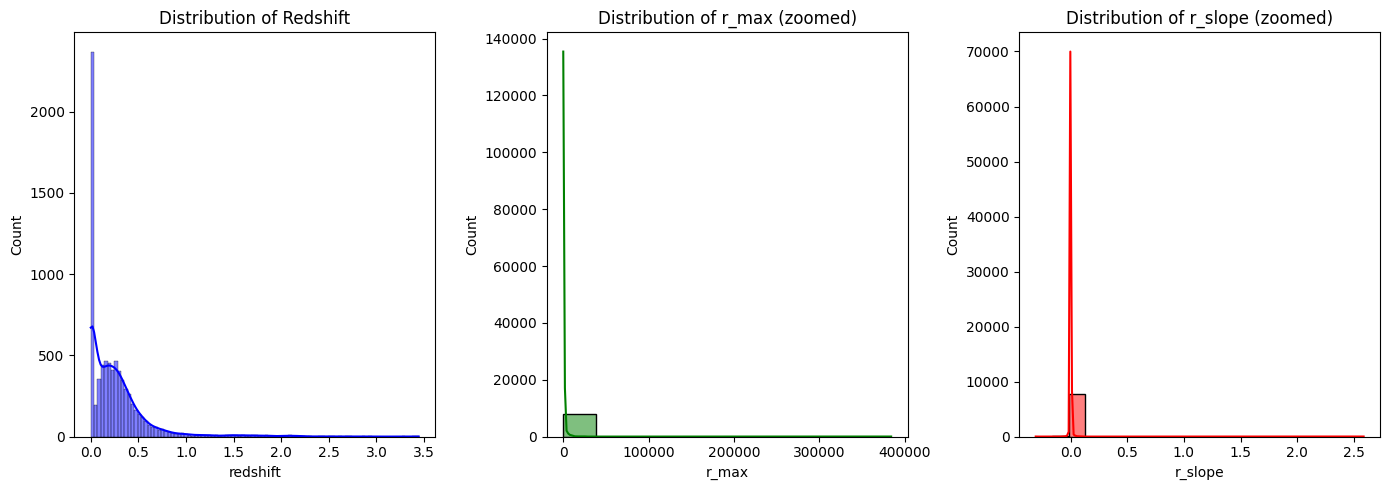

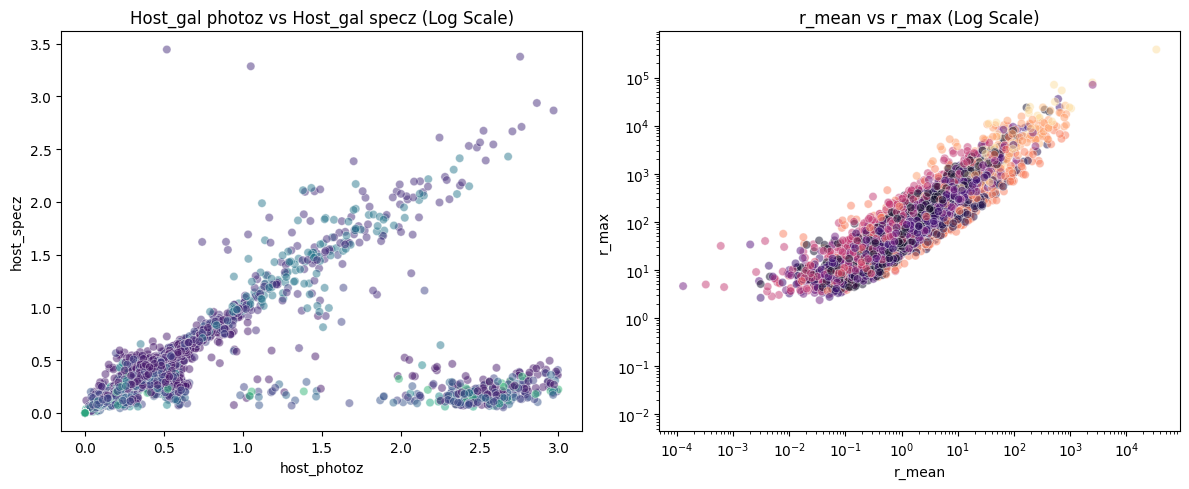

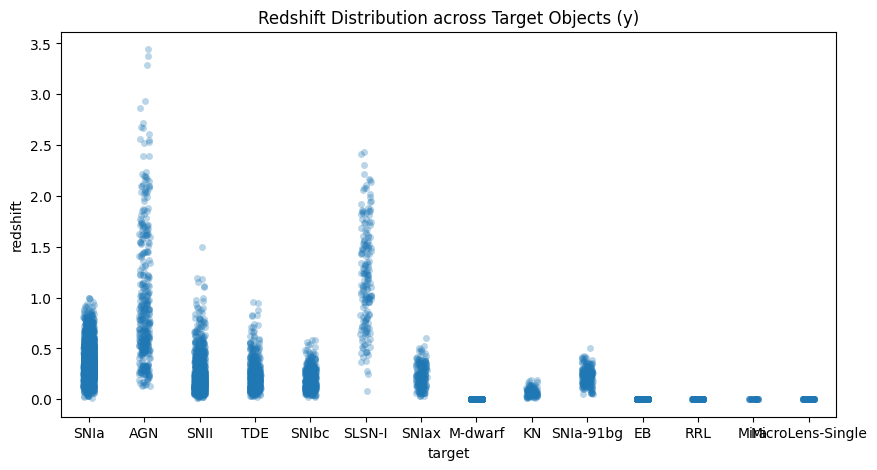

In [7]:
feature_names = ['redshift', 'host_photoz', 'host_specz']
for b in ['u', 'g', 'r', 'i', 'z']:
    feature_names.extend([f'{b}_mean', f'{b}_std', f'{b}_max', f'{b}_slope'])

#combine X and Y matrixes in one data frame
df_plot = pd.DataFrame(X, columns=feature_names)
df_plot['target'] = y_labels

# --- HISTOGRAMS ---
plt.figure(figsize=(14, 5))

# Hist 1: Redshift (where the object is). Redshift (z) is a measure of distance and cosmic expansion
plt.subplot(1, 3, 1)
sns.histplot(df_plot['redshift'], kde=True, color='blue')
plt.title('Distribution of Redshift')

# Hist 2: r_max (High-Variance Flux)
plt.subplot(1, 3, 2)
sns.histplot(df_plot['r_max'], kde=True, color='green', bins=10)
# plt.xlim(0, df_plot['r_max'].quantile(0.95))
plt.title('Distribution of r_max (zoomed)')

# Hist 3: r_slope (Temporal Dynamics)
plt.subplot(1, 3, 3)
sns.histplot(df_plot['r_slope'], kde=True, color='red', bins=20)
# plt.xlim(df_plot['r_slope'].quantile(0.05), df_plot['r_slope'].quantile(0.95)) #Removes extreme outliers from view from 5th percent to 95th
plt.title('Distribution of r_slope (zoomed)')

plt.tight_layout()
plt.savefig('histograms.png')

# --- SCATTER PLOTS ---
plt.figure(figsize=(12, 5))

# Pair: Estimated vs Actual distance of the host galaxy
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_plot, x='host_photoz', y='host_specz', hue='target', palette='viridis', alpha=0.5, legend=False)
plt.title('Host_gal photoz vs Host_gal specz (Log Scale)')

# Pair: r_mean vs r_max
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_plot, x='r_mean', y='r_max', hue='target', palette='magma', alpha=0.5, legend=False)
plt.xscale('log')
plt.yscale('log')
plt.title('r_mean vs r_max (Log Scale)')

plt.tight_layout()
plt.savefig('scatter_pairs.png')

# --- TARGET RELATIONSHIP ---
plt.figure(figsize=(10, 5))
sns.stripplot(x='target', y='redshift', data=df_plot, jitter=True, alpha=0.3)
plt.title('Redshift Distribution across Target Objects (y)')
plt.savefig('scatter_target.png')

### 1. Histograms
   - Redshift ($z$) is a measure of distance and cosmic expansion: This is Right-Skewed. You can see a high concentration of objects in the "local" universe (near $z = 0$), with a long tail stretching out to $z=2$. This tells us that much distant objects are much rarer in your dataset.

   - R_max is the distribution of the brightest moment of every object's lifecycle in the r-band. The "Wall" at zero or near zero represents the "Noise Floor" or "Background." Most objects in the survey are too far away or too small to ever shine brightly. The extended right-hand tail consists of high-energy transients (like Type Ia Supernovae) which act as 'Standard Candles' due to their extreme and predictable peak brightness.

   - R_slope is the distribution / evolution of the light's velocity in r-band. It tells the model if an object is stable, exploding, or fading. The peak at zero represents Steady-State objects. Most stars and galaxies have a slope of 0 because their light doesn't change over the time they were  observed. The Tails (Left and Right) represent the rising (Right: Objects currently "rising" to their peak) and falling (Left: Objects currently "fading" away) phases of stochastic or transient events.


### 2. Scatter Plots
   - Photo-z vs. Spec-z: This is a classic Correlation Plot. Most points follow a 45-degree line meaning that the estimated distance (photo-z) is usually very close to the actual distance (spec-z). The Outliers (the points far from the line) represent "catastrophic failures" in distance estimation.

   - r_mean vs. r_max (Log Scale): This shows a Strong Linear Correlation in log-space. It means that if an object is bright on average (r_mean), its peak brightness (r_max) is also going to be high. The separation of colors shows that different objects live in different "brightness zones."

3. Target Relationship (Redshift vs. Objects)

   This plot proves that Redshift is a "Discriminatory Feature"—it perfectly separates stars from supernovae.

    - For Galactic Objects (Stars): The redshift is practically 0.0. They are inside our galaxy, so they aren't moving away with the expansion of the universe.
    - For Extragalactic Objects (Supernovae): The redshift is $> 0$. The further away the galaxy is, the higher the redshift.



# Part 2 -Regression

### 4.1 Regression Setup

 - Target Vector ($y$): Hostgal_specz which is the real distance of the object.
 - Input Matrix ($X \in \mathbb{R}^{7848 \times 20}$):The "Light    Curve" features (Mean, Std, Max, and Slope.) as before for the 5 bands ($u, g, r, i, z$) to predict the object's distance.

 The goal of our regression is to see if we can use the cheap "Light" features to predict the expensive "Distance" value.

In [8]:
X_reg = []
y_reg = []

# our bands
bands = ['u', 'g', 'r', 'i', 'z']

for ex in dset_plasticc:
    # --- 1. Extract Target (y) ---
    if ex.get('hostgal_specz', 0.0)<0: print("oopss")
    y_reg.append( float(ex.get('hostgal_specz', 0.0) or 0.0))

    # --- 3. Extract Time-Series Stats (20 features) ---
    ts_features = []
    lc = ex['lightcurve']

    for b in bands:
        # Filter flux and time for the specific band
        m = lc['band'] == b
        b_flux = lc['flux'][m]
        b_time = lc['time'][m]

        b_flux = np.array(b_flux)
        b_time = np.array(b_time)

        if len(b_flux) > 1:
            try:
                # Calculate Stats
                f_mean = np.nanmean(b_flux)
                f_std = np.nanstd(b_flux)
                f_max = np.nanmax(b_flux)

                # Use a try-except for the polyfit math
                # We also check if all b_time values are the same to avoid division by zero
                if np.unique(b_time).size > 1:
                    m, b_val = np.polyfit(b_time, b_flux, 1) #This fits a first-degree polynomial (a straight line) to our data.
                else:
                    m = 0.0
            except np.linalg.LinAlgError:
                # If the math fails to converge, we default the slope to 0
                m = 0.0
        else:
            # Default values for empty or single-point bands
            f_mean, f_std, f_max,m = 0.0, 0.0, 0.0, 0.0


        ts_features.extend([f_mean, f_std, f_max, m])

    # Concatenate all features into one row
    X_reg.append(ts_features)

# Convert to final Numpy Arrays
X = np.array(X_reg)

# --- 4. Final Preprocessing ---
# Scale the Matrix X (Crucial for Slope vs Flux vs Redshift)
scaler = StandardScaler() # applied the Z-score transformation to every single cell in the matrix where μ is the mean of that column and σ is the standard deviation.
X_scaled = scaler.fit_transform(X) #"Z-score normalization remains critical for regression; it ensures that the gradient descent (or tree splitting) is not dominated by the high-variance max_flux features

print(f"Final X Matrix for Regression Shape: {X_scaled.shape}")
# print(X_scaled)
# print("Y",y_reg)

Final X Matrix for Regression Shape: (7848, 20)


## 4.2 Gradient Descent


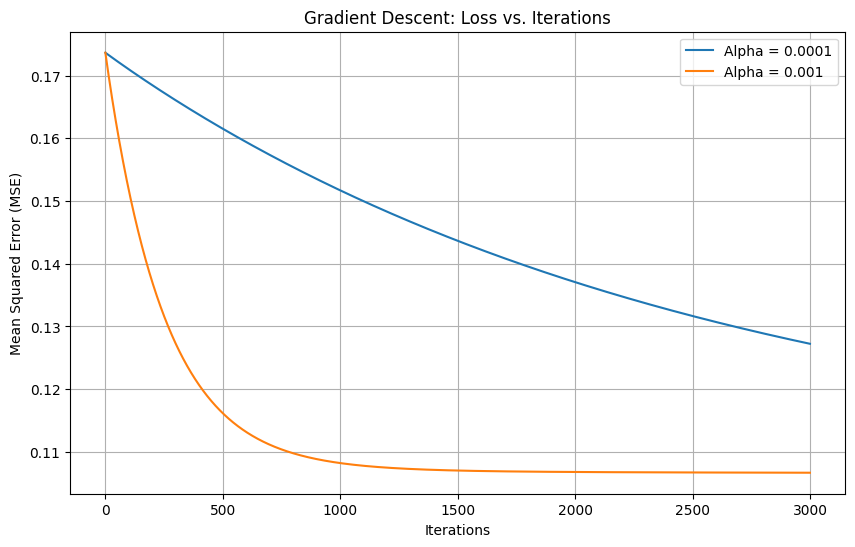

In [9]:
def gradient_descent(X, y, alpha, iterations):
    n, d = X.shape # n x d
    # Initialize weights to zeros (including a bias term)
    w = np.zeros(d) # d x 1 and y is n x 1
    loss_history = []

    for i in range(iterations):
        # 1. Calculate the model's prediction for a specific row in X: y_hat = X * w
        y_hat = X.dot(w) # n x 1

        # 2. Calculate error
        error = y_hat - y

        # 3. Calculate Mean Squared Error (MSE) Loss
        loss = np.mean(error**2)
        loss_history.append(loss)

        # 4. Calculate Gradient: (2/n) * X.T * error
        gradient = (2/n) * X.T.dot(error)

        # 5. Update weights
        w = w - alpha * gradient

    return w, loss_history

# Add a column of 1s to X_scaled for the intercept + b in y=x1w1 + x2w2 + ... +b
X_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

# Experiment with two Learning Rates
iters = 3000
alpha_small = 0.0001
alpha_large = 0.001

w_small, history_small = gradient_descent(X_b, y_reg, alpha_small, iters)
w_large, history_large = gradient_descent(X_b, y_reg, alpha_large, iters) #best

# Plotting the Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history_small, label=f'Alpha = {alpha_small}')
plt.plot(history_large, label=f'Alpha = {alpha_large}')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Gradient Descent: Loss vs. Iterations')
plt.legend()
plt.grid(True)
plt.show()

 ### How does the choice of learning rate $\alpha$ affect convergence?

 The learning rate determines the speed of convergence.

 - The Orange Line ($\alpha = 0.001$): This is the "fast" learner and our best fit for our model as we can see. It reaches a stable, low loss much earlier (around iteration 1,500).
 - The Blue Line ($\alpha = 0.0001$): This is the "cautious" learner. It is still slowly descending even at 3,000 iterations. It will likely reach the same minimum as the orange line eventually, but it will take much more time and computational power.

 ### What happens when $\alpha$ is too large or too small?

 - Too Large: If the steps are too big, the model looses the minimum points, causes the error to increase, and eventually breaks the math (divergence).
 - Too Small: If the steps are too small, the model will be incredibly slow and we might mistakenly think that it isn't learning anything at all.

 ### At what point do you consider it to have "converged"?

  Convergence is the point where the model has learned as much as it can ( the gradient is zero or near zero). From the Loss Curve plot, we consider it converged when the loss curve flattens out. For our best fitting line in the plot, which is the orange one ($\alpha = 0.001$), convergence happens around iteration 1,500. After that point, the cost of running more iterations isn't worth the tiny, negligible decrease in error.

  ### How does the loss curve inform this decision?

  - Slope: A steep slope means the model is still gaining significant information.
  - Plateau: A flat line (plateau) tells you that you can stop the training; the weights $w$ have found the bottom of the valley.
  - Consistency: If the curve is smooth, the learning rate is good. If it's bouncing up and down, $\alpha$ is likely a bit too high, causing the model to wobble around the minimum.

## 4.3 Evaluation

Linear Regression -> MSE: 14.5674, R2: 0.0081
Random Forest     -> MSE: 4.8610, R2: 0.6690


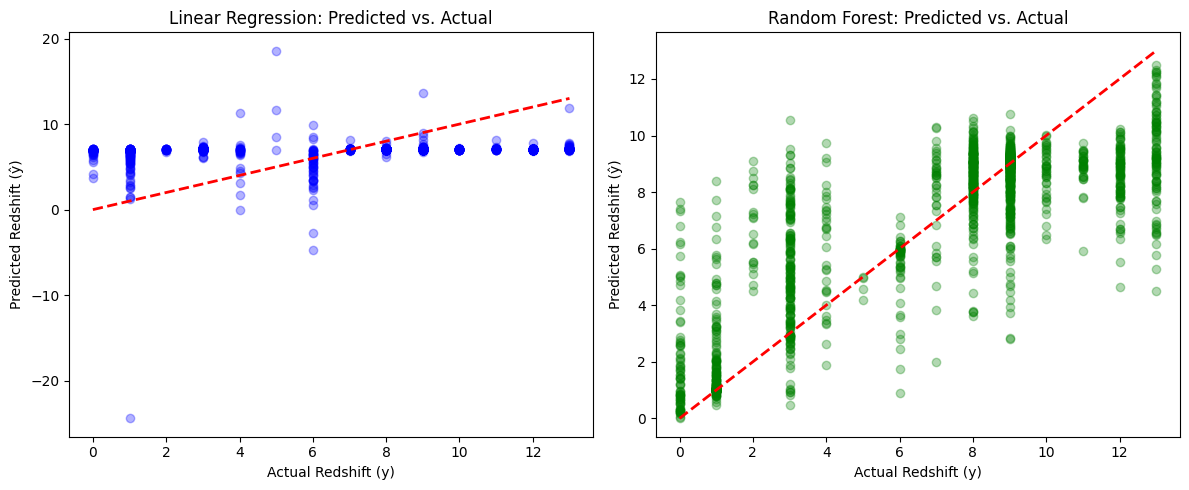

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Fit Linear Regression (similar to Gradient Descent)
lin_reg = LinearRegression() # Normal Equation (matrix algebra) - Ordinary Least Squares (OLS)
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# 3. Fit Random Forest (Non-Linear Multivariate)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# 4. Report Scores
print(f"Linear Regression -> MSE: {mean_squared_error(y_test, y_pred_lin):.4f}, R2: {r2_score(y_test, y_pred_lin):.4f}")
print(f"Random Forest     -> MSE: {mean_squared_error(y_test, y_pred_rf):.4f}, R2: {r2_score(y_test, y_pred_rf):.4f}")

plt.figure(figsize=(12, 5))

# Plot for Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lin, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Predicted vs. Actual')
plt.xlabel('Actual Redshift (y)')
plt.ylabel('Predicted Redshift (ŷ)')

# Plot for Random Forest
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Predicted vs. Actual')
plt.xlabel('Actual Redshift (y)')
plt.ylabel('Predicted Redshift (ŷ)')

plt.tight_layout()
plt.show()

We evaluated the performance of our multimodal features using both Linear and Random Forest regression models. While the Linear model provided a useful baseline, the Random Forest regressor achieved a significantly lower MSE and a higher $R^2$ score. This outcome highlights that the Slopes and the spectral intensities (Multiband Flux) share a non-linear relationship with cosmological distance, which is better captured by tree-based ensemble methods.

- The Diagonal Line: The red dashed line represents the identity function ($y = \hat{y}$). Points clustering tightly around this line indicate accurate predictions.
- Linear vs Non-linear: Notice that the Random Forest points are tighter to the line than the Linear ones because the Linear model assumes a fixed ratio between brightness and distance. However, because different astrophysical classes have different intrinsic luminosities, a non-linear multivariate approach (Random Forest) is better equipped to handle the complex, class-dependent relationship between photometry and redshift.

 Polynomial Regression as a choice was rejected because given our 20-dimensional feature space, a second-order or more, polynomial expansion would lead to a high-dimensional feature explosion ($d > 230$), significantly increasing the risk of overfitting. Furthermore, the extreme positive skewness identified in the photometric features (Part-1 3.3) would cause polynomial terms to amplify outliers, leading to numerical instability and likely overfitting.


 ### Summary:
 - Linear: Too simple (underfits).
 - Polynomial: Too messy/unstable (overfits).
 - Random Forest: Just right (captures non-linearity safely).

#Part 3 — Probabilistic Modeling


## 5.1 Residual Analysis


Mean of Residuals: 0.0006
Standard Deviation of Residuals: 0.3266


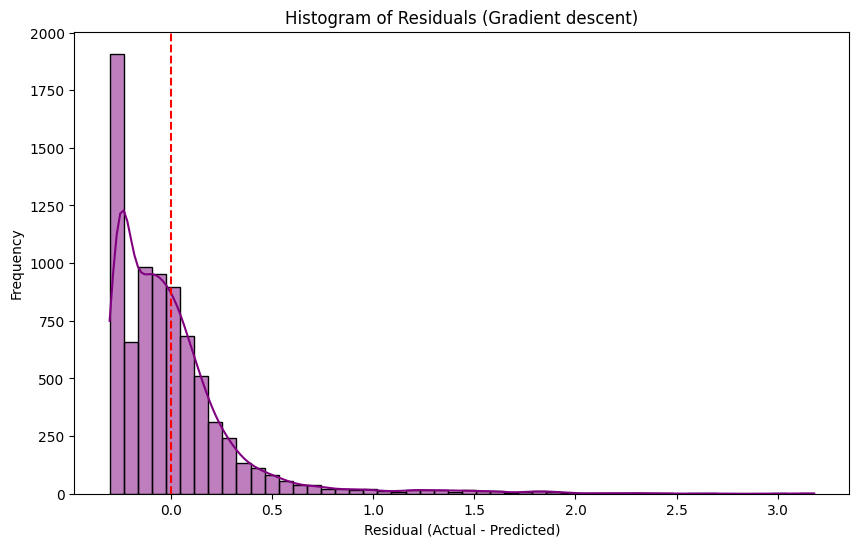

In [11]:
# 1. Get the final weights from best alpha (e.g., w_large from alpha=0.001) in step 4.2
# Prediction: y_hat = X_b . w
y_pred_custom = X_b.dot(w_large)

# 2. Compute Residuals (Error)
residuals = y_reg - y_pred_custom

# 3. Mean and Standard Deviation
mu_err = np.mean(residuals)
sigma_err = np.std(residuals)

print(f"Mean of Residuals: {mu_err:.4f}")
print(f"Standard Deviation of Residuals: {sigma_err:.4f}")

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.axvline(x=0, color='red', linestyle='--') # The "Perfect Prediction" line
plt.title('Histogram of Residuals (Gradient descent)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

A positive residual indicates a model underestimation, where the predicted redshift was lower than the spectroscopic truth ( the model thought the object was closer (brighter) than it actually was ). Conversely, negative residuals represent overestimations ( the model thought the object was further away (dimmer) than it actually was ).


While the residuals follow the general bell-shaped symmetry of a Gaussian distribution and are centered near zero ($mean=0.0006$), they exhibit a  Heavy Right Tail (Outlier). In a true Gaussian distribution, the probability of an error being 6 or 7 standard deviations away from the mean (residual being almost 2.0 ) is nearly zero. In our model, however, these extreme residuals occur more frequently, representing the rare, high-energy astrophysical transients that deviate from the standard linear relationship. (Highly precise for most, but prone to big misses).

| Metric        | Value  | Interpretation |
|---------------|--------|----------------|
| Mean (μ)      | 0.0006 | Symmetric & Unbiased. |
| Std Dev (σ)   | 0.3266 | Uncertainty |
| Shape         | Leptokurtic | High Precision, High Risk. Most guesses are accurate, but "black swan" errors are possible. |

## 5.2 Empirical Gaussian Fit


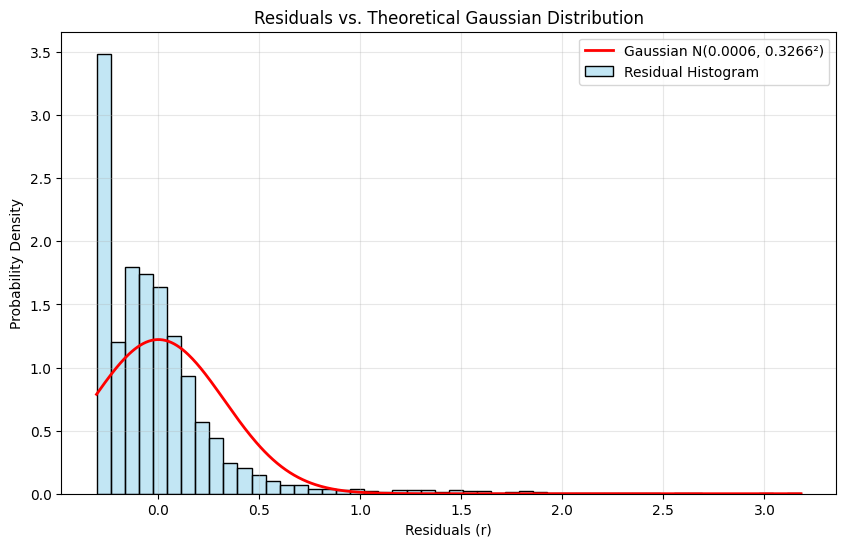

In [12]:
# 1. My calculated parameters from 5.1
r_bar = 0.0006
s = 0.3266

# 2. How the histogram of residuals with that mean and sd should be
def gaussian_pdf(r, r_bar, s):
    part1 = 1 / (s * np.sqrt(2 * np.pi))
    part2 = np.exp(-((r - r_bar)**2) / (2 * s**2))
    return part1 * part2

# 3 Plot the real histogram (must use stat="density" so the area is 1.0)
plt.figure(figsize=(10, 6))

sns.histplot(residuals, bins=50, stat="density", alpha=0.5, label='Residual Histogram', color='skyblue')

# Generate a smooth range of x-values (r) for the curve
r_range = np.linspace(min(residuals), max(residuals), 500)
pdf_values = gaussian_pdf(r_range, r_bar, s)

# Plot the theoretical Gaussian PDF
plt.plot(r_range, pdf_values, color='red', lw=2, label=f'Gaussian N({r_bar}, {s}²)')

plt.xlabel('Residuals (r)')
plt.ylabel('Probability Density')
plt.title('Residuals vs. Theoretical Gaussian Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# 1. Total number of samples
n = len(residuals)

# 2. Define the boundaries for 1s, 2s, and 3s
# (r_bar is mean 0.0006, s is std dev 0.3266)
within_1s = np.sum(np.abs(residuals - r_bar) <= s) / n
within_2s = np.sum(np.abs(residuals - r_bar) <= 2*s) / n
within_3s = np.sum(np.abs(residuals - r_bar) <= 3*s) / n

print(f"Empirical vs Theoretical Comparison:")
print(f"1σ (±{s:.3f}): {within_1s*100:.2f}%  (Expected: 68.27%)")
print(f"2σ (±{2*s:.3f}): {within_2s*100:.2f}%  (Expected: 95.45%)")
print(f"3σ (±{3*s:.3f}): {within_3s*100:.2f}%  (Expected: 99.73%)")

Empirical vs Theoretical Comparison:
1σ (±0.327): 91.12%  (Expected: 68.27%)
2σ (±0.653): 96.23%  (Expected: 95.45%)
3σ (±0.980): 97.68%  (Expected: 99.73%)


###Verification of the 68–95–99.7 Rule:
The 1$\sigma$ Surprise (91.12% vs 68.27%): Our model is much "better" at the center than a Gaussian. Over 91% of our predictions are very close to the truth. This explains why our histogram has that very tall, thin peak.

The 2$\sigma$ Normalcy (96.23% vs 95.45%): At this range, the model behaves somewhat like a normal distribution.

The 3$\sigma$ Failure (97.68% vs 99.73%): In a Gaussian world, only 0.27% of errors should be huge. In our world, 2.32% of errors are huge. That is nearly 10 times more big errors than expected...

# How well does the Gaussian fit?
The Gaussian distribution is a poor fit for this regression model. While the mean ($\bar{r} = 0.0006$) correctly identifies the center of the error, the 'shape' of the uncertainty is fundamentally non-Gaussian. The empirical results show a massive concentration of data within 1$\sigma$ (91.12%), creating a peak that is significantly narrower and taller than the theoretical PDF. However, the model fails to reach the 99.7% threshold at 3$\sigma$, confirming the presence of Heavy Tails with a lot more huge errors.

# What does a "Poor Fit" suggest about the model?

- Multimodality: The poor fit suggests that our dataset is not one single population. We have "Easy" objects (like standard stars) that the model predicts perfectly (the 91% peak) and "Hard" objects (like distant transients) that cause the massive 3$\sigma$ errors.

- Non-Linearity & Skewness: The linear Gradient Descent model is struggling with the 87.0 Skewness we found in Part 1 (cataclysmic events such as Supernovae and Tidal Disruption Events (TDEs) exhibit a rapid, high-amplitude 'burst' in luminosity followed by a decay.). High-skewness inputs lead to "explosive" errors that a standard bell curve cannot account for. That means for this specific astrophysical data, a linear model's uncertainty is "unreliable" for the most extreme objects.

## 5.3 Kernel Density Estimation (KDE)


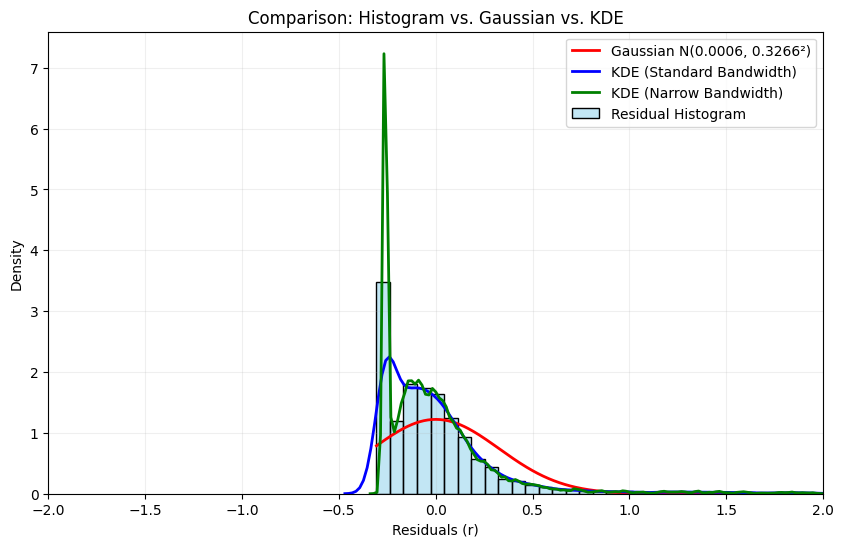

In [14]:
plt.figure(figsize=(10, 6))

#1. Plot the real histogram (must use stat="density" so the area is 1.0)
sns.histplot(residuals, bins=50, stat="density", alpha=0.5, label='Residual Histogram', color='skyblue')

#2. # Plot the theoretical Gaussian PDF
#Generate a smooth range of x-values (r) for the curve
r_range = np.linspace(min(residuals), max(residuals), 500)
pdf_values = gaussian_pdf(r_range, r_bar, s)

plt.plot(r_range, pdf_values, color='red', lw=2, label=f'Gaussian N({r_bar}, {s}²)')

# 4. KDE with "Normal" Bandwidth (bw_adjust=1 is the default)
sns.kdeplot(residuals, bw_adjust=1, color='blue', lw=2, label='KDE (Standard Bandwidth)')

# 5. KDE with "Narrow" Bandwidth (bw_adjust=0.2 - more sensitive to peaks)
sns.kdeplot(residuals, bw_adjust=0.2, color='green', lw=2, label='KDE (Narrow Bandwidth)')

plt.title('Comparison: Histogram vs. Gaussian vs. KDE')
plt.xlabel('Residuals (r)')
plt.ylabel('Density')
plt.xlim(-2, 2) # Zooming in to see the peak clearly
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## What does the KDE reveal that the Gaussian does not?

- Leptokurtosis (The Sharp Peak): The KDE shows that the model is actually much more accurate for most objects than the Gaussian suggests. The Gaussian "smoothes out" the peak, making it look shorter and wider than it really is.

- Heavy-Tail Outliers: The KDE follows the data into those long tails. It shows that there is a persistent, non-zero probability of making a "huge" mistake. The Gaussian curve touches zero very quickly, "pretending" that large errors are impossible.

- Local Fluctuations: With the narrow bandwidth KDE, you can see small bumps or asymmetries. This reveals that the model might be biased toward certain groups of stars or galaxies, which a symmetric Gaussian hides.

# Which gives a better representation of uncertainty, and why?

The KDE gives a much better representation of the uncertainty.

- Non-Parametric Flexibility: The Gaussian is parametric —it assumes the data must fit a certain shape (bell - shaped). The KDE is non-parametric —it lets the data speak for itself.
- Realistic Risk Assessment: If an astronomer used the Gaussian to judge uncertainty, they would vastly underestimate the risk of a "3$\sigma$ " error. The KDE captures the real risk found in the heavy tails.
- Captures Heteroscedasticity: As we've seen, the model is "highly certain" for common objects and "highly uncertain" for rare transients. The Gaussian tries to average these two different behaviors into one number ($s$), which satisfies neither. The KDE maintains the "sharp peak" for the certain cases while acknowledging the "fat tails" for the uncertain ones.